In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

plt.style.use("ggplot")

In [3]:
# Load cleaned dataset

df = pd.read_csv("../processed/cleaned_youtube_data.csv")

In [4]:
# Display first five rows

df.head()

,video_duration_min,avg_view_duration_sec,avg_view_percentage,subscribers_gained,traffic_source,ctr_percentage,impressions,likes,comments,shares,total_watch_time_hours,content_category
0,45.55,2422,88.62,564,Shorts Feed,28.70,1975899,88186,1055,63,1329340.94,Sports
1,59.12,562,15.84,523,Notifications,25.67,1552915,69884,5883,131,242427.29,Vlog
2,40.06,2369,98.56,628,External,10.13,90886,37931,3746,2555,59808.04,News
3,42.54,2097,82.16,239,External,25.00,999294,38861,1575,900,582088.76,Education
4,31.40,1424,75.58,138,Shorts Feed,23.49,1656171,57043,3150,1452,655107.64,Sports


In [5]:
# Display dataset information

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   video_duration_min      29999 non-null  float64
 1   avg_view_duration_sec   29999 non-null  int64  
 2   avg_view_percentage     29999 non-null  float64
 3   subscribers_gained      29999 non-null  int64  
 4   traffic_source          29999 non-null  str    
 5   ctr_percentage          29999 non-null  float64
 6   impressions             29999 non-null  int64  
 7   likes                   29999 non-null  int64  
 8   comments                29999 non-null  int64  
 9   shares                  29999 non-null  int64  
 10  total_watch_time_hours  29999 non-null  float64
 11  content_category        29999 non-null  str    
dtypes: float64(4), int64(6), str(2)
memory usage: 2.7 MB


# Distribution of Numerical Features

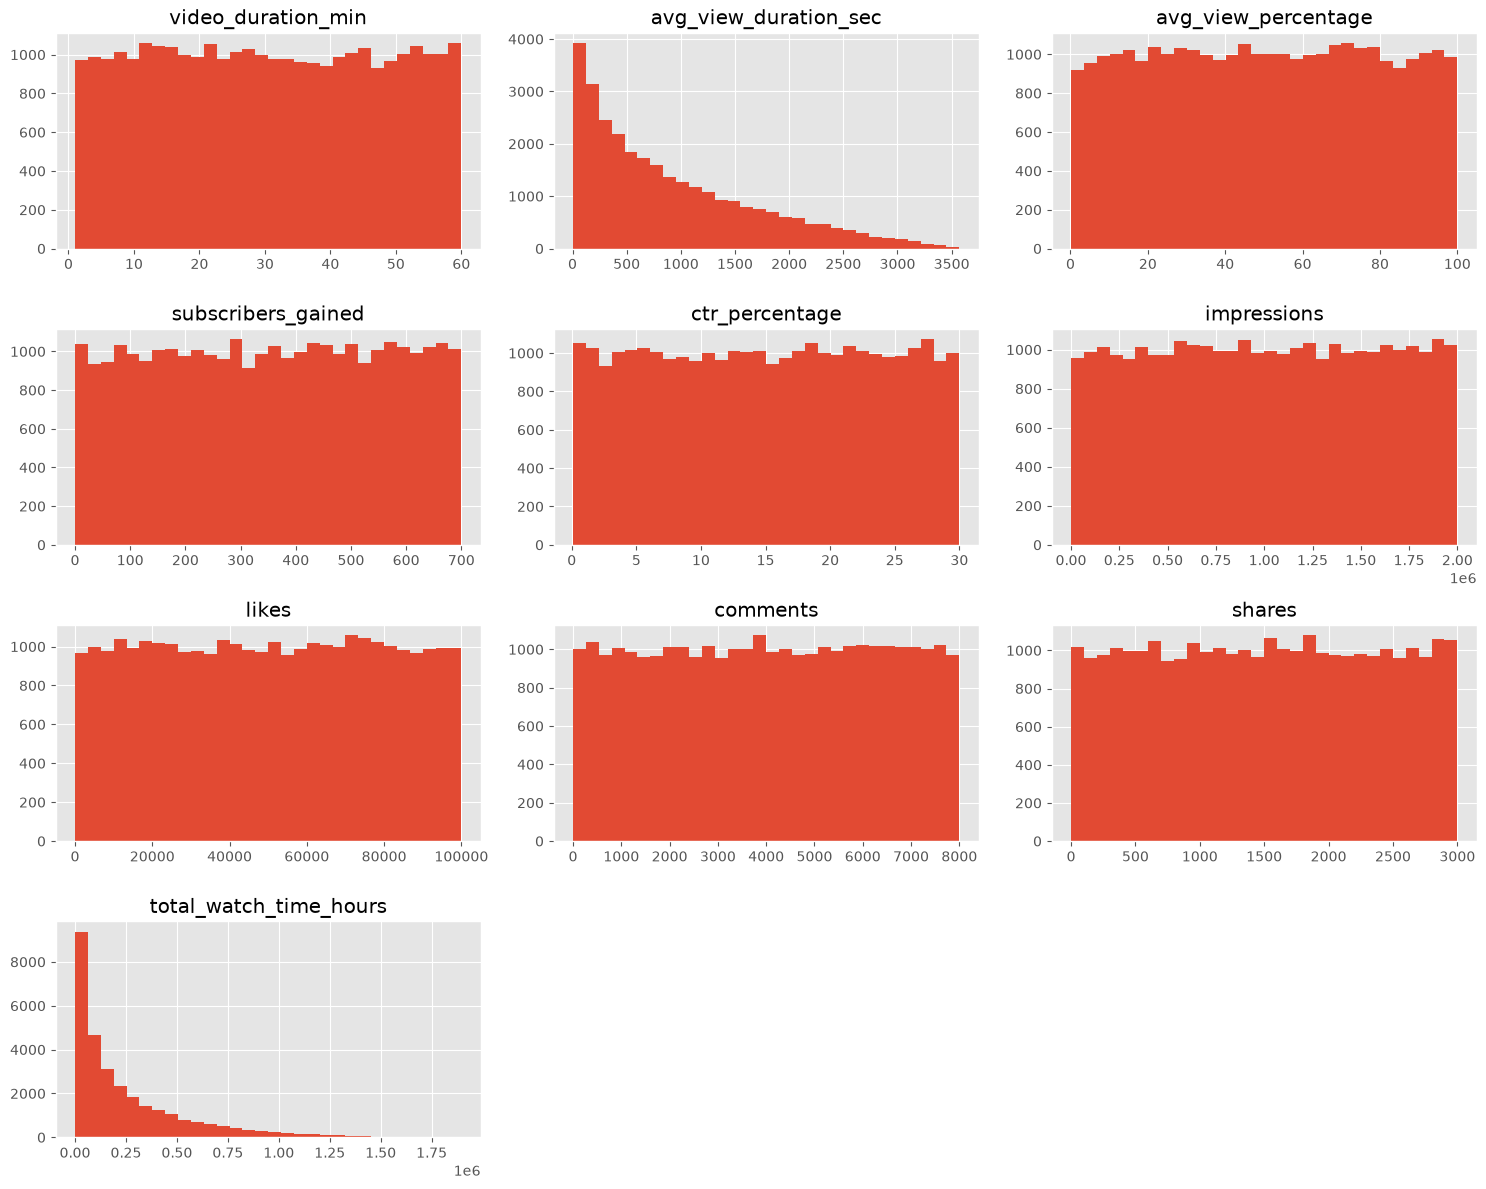

In [14]:
# Histograms of all numerical columns

df.hist(figsize=(15,12), bins=30)
plt.savefig(
    "../images/histograms.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

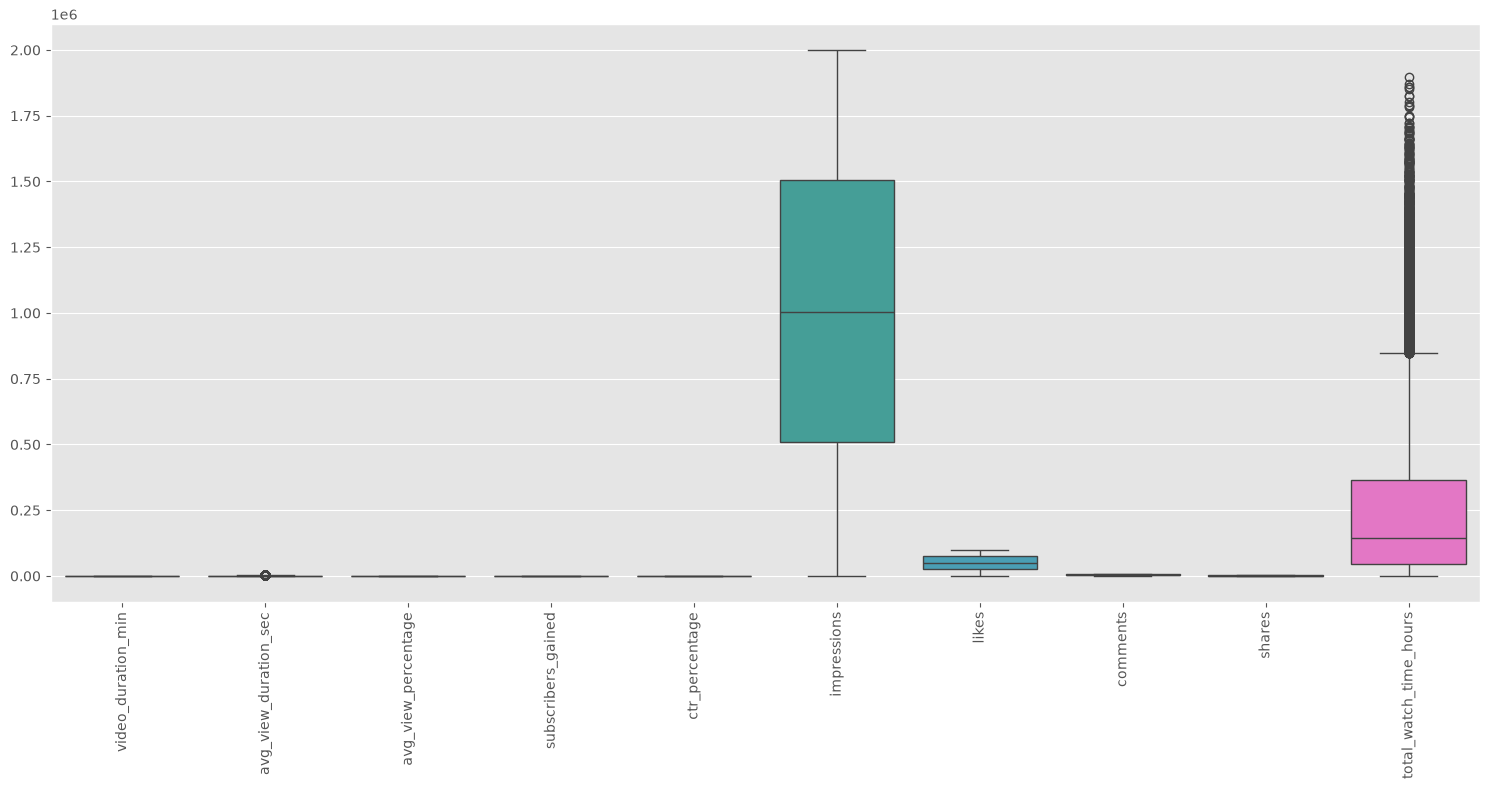

In [16]:
# Boxplots of numerical features

numerical_columns = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,8))

sns.boxplot(data=df[numerical_columns])

plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig(
    "../images/boxplots.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [8]:
# Correlation matrix

correlation_matrix = df.corr(numeric_only=True)

correlation_matrix

,video_duration_min,avg_view_duration_sec,avg_view_percentage,subscribers_gained,ctr_percentage,impressions,likes,comments,shares,total_watch_time_hours
video_duration_min,1.000000,0.652188,-0.001425,0.005472,0.000415,-0.006776,-0.002524,0.003713,-0.003111,0.487761
avg_view_duration_sec,0.652188,1.000000,0.660600,0.000843,0.005798,-0.001118,-0.006572,0.003366,-0.003442,0.750055
avg_view_percentage,-0.001425,0.660600,1.000000,-0.002224,0.008267,0.001561,-0.006657,-0.001925,0.002254,0.496298
subscribers_gained,0.005472,0.000843,-0.002224,1.000000,0.000880,0.001687,-0.016235,0.009977,-0.007862,-0.000071
ctr_percentage,0.000415,0.005798,0.008267,0.000880,1.000000,-0.003355,-0.000619,0.003349,0.013354,0.003429
impressions,-0.006776,-0.001118,0.001561,0.001687,-0.003355,1.000000,0.003836,-0.007695,-0.012680,0.500499
likes,-0.002524,-0.006572,-0.006657,-0.016235,-0.000619,0.003836,1.000000,0.003918,-0.010892,-0.002550
comments,0.003713,0.003366,-0.001925,0.009977,0.003349,-0.007695,0.003918,1.000000,-0.000072,-0.001149
shares,-0.003111,-0.003442,0.002254,-0.007862,0.013354,-0.012680,-0.010892,-0.000072,1.000000,-0.004894
total_watch_time_hours,0.487761,0.750055,0.496298,-0.000071,0.003429,0.500499,-0.002550,-0.001149,-0.004894,1.000000


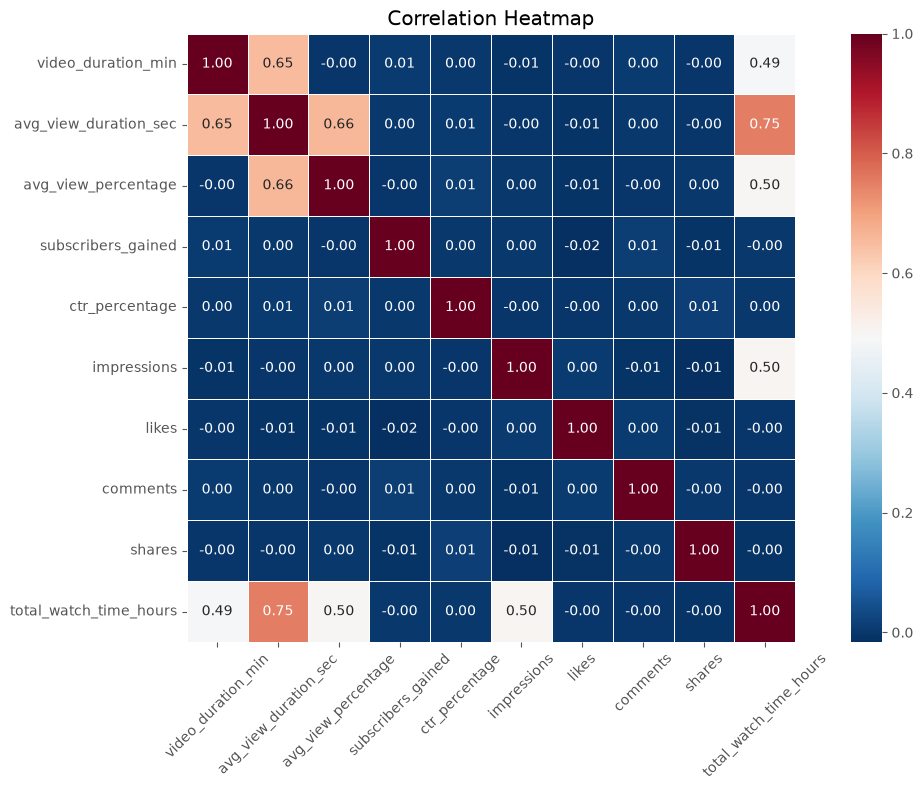

In [17]:
# Correlation Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="RdBu_r",
    linewidths=0.5,
    square=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.xticks(rotation=45)

plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

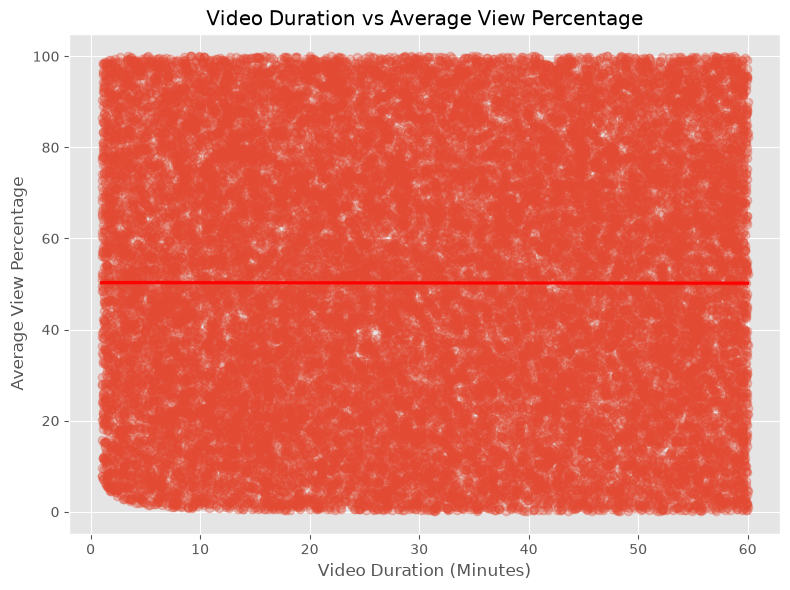

In [26]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="video_duration_min",
    y="avg_view_percentage",
    scatter_kws={"alpha":0.3},
    line_kws={"color":"red"}
)

plt.title("Video Duration vs Average View Percentage")

plt.xlabel("Video Duration (Minutes)")
plt.ylabel("Average View Percentage")

plt.tight_layout()

plt.savefig(
    "../images/video_duration_regression.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

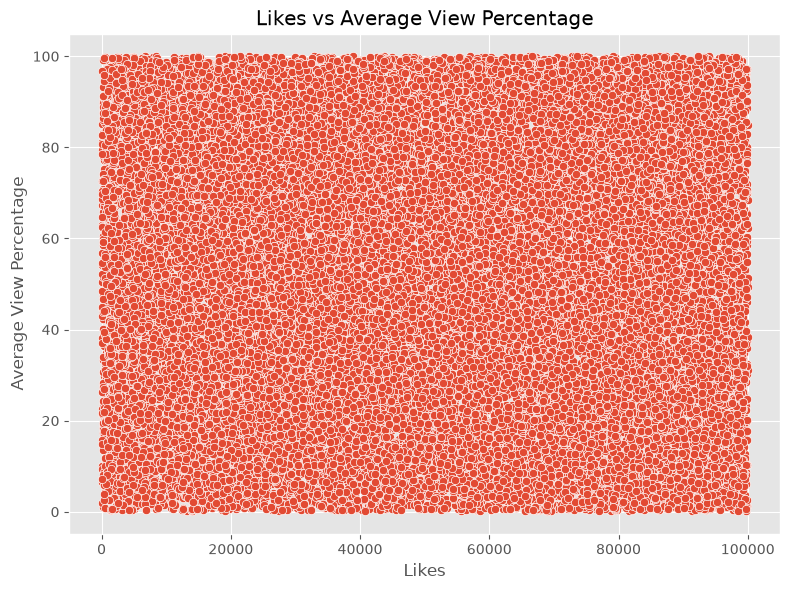

In [25]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="likes",
    y="avg_view_percentage"
)
plt.title("Likes vs Average View Percentage")
plt.xlabel("Likes")

plt.ylabel("Average View Percentage")

plt.tight_layout()

plt.savefig(
    "../images/likes_vs_avg_view_percentage.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

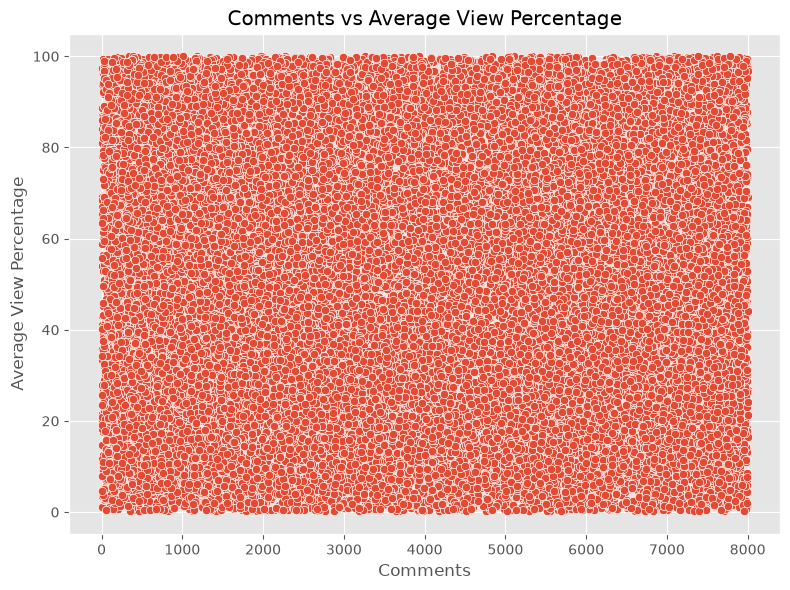

In [20]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="comments",
    y="avg_view_percentage"
)

plt.title("Comments vs Average View Percentage")
plt.xlabel("Comments")

plt.ylabel("Average View Percentage")

plt.tight_layout()

plt.savefig(
    "../images/comments_vs_avg_view_percentage.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

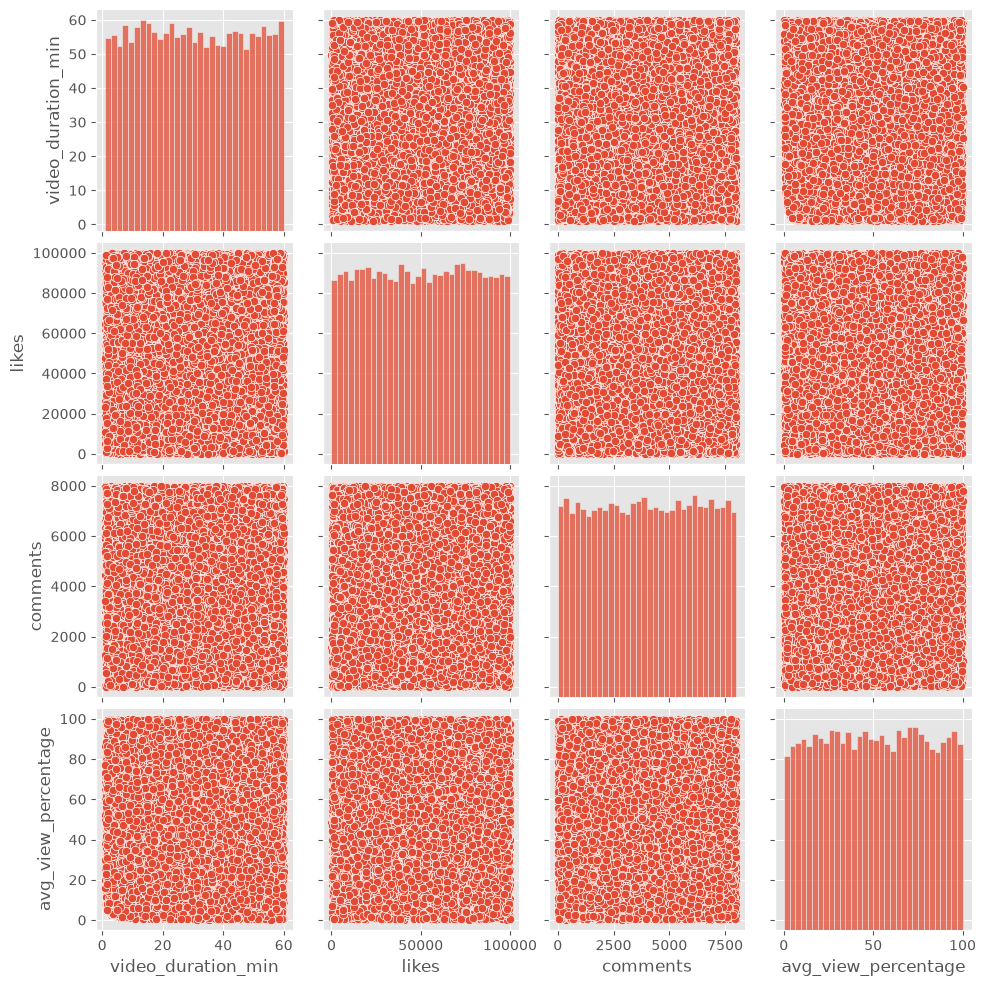

In [19]:
selected_columns = [
    "video_duration_min",
    "likes",
    "comments",
    "avg_view_percentage"
]

sns.pairplot(df[selected_columns])
plt.savefig(
    "../images/pairplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
# Correlation with target variable

target_correlation = correlation_matrix["avg_view_percentage"].sort_values(ascending=False)

target_correlation

avg_view_percentage       1.000000
avg_view_duration_sec     0.660600
total_watch_time_hours    0.496298
ctr_percentage            0.008267
shares                    0.002254
impressions               0.001561
video_duration_min       -0.001425
comments                 -0.001925
subscribers_gained       -0.002224
likes                    -0.006657
Name: avg_view_percentage, dtype: float64

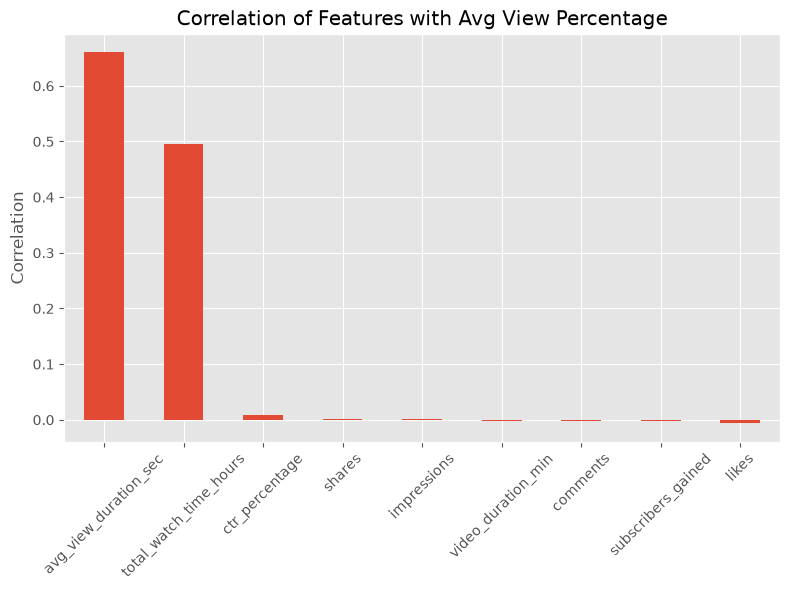

In [22]:
plt.figure(figsize=(8,6))

target_correlation.drop("avg_view_percentage").plot(kind="bar")

plt.title("Correlation of Features with Avg View Percentage")

plt.ylabel("Correlation")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../images/target_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()